# DD2525 Analysis

Todo

In [1]:
import json
import pathlib
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results_dir = pathlib.Path("../results")
rows = []
for repo_dir in sorted(results_dir.iterdir()):
    json_file = repo_dir / "latest.json"
    error_file = repo_dir / "latest.error.log"
    # if the error log exists, it failed and we can skip it
    if error_file.exists():
        print(f"Skipping failed {repo_dir}")
        continue
    with open(json_file) as f:
        raw = json.load(f)
    for cap in raw.get("capabilityInfo", []):
        rows.append({
            "repo": repo_dir.name.replace("_", "/"),
            "capability": cap["capabilityName"],
            "package_dir": cap["packageDir"],
            "capability_type": cap["capabilityType"],
            "depth": len(cap["path"]),
        })
df = pd.DataFrame(rows)
print(f"Loaded {df['repo'].nunique()} repos")

Skipping failed ../results/beego_beego
Loaded 49 repos


In [3]:
df

,repo,capability,package_dir,capability_type,depth
0,IBM/sarama,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,5
1,IBM/sarama,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,7
2,IBM/sarama,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,5
3,IBM/sarama,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,6
4,IBM/sarama,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,6
...,...,...,...,...,...
129439,zeromicro/go-zero,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15
129440,zeromicro/go-zero,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15
129441,zeromicro/go-zero,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,16
129442,zeromicro/go-zero,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15


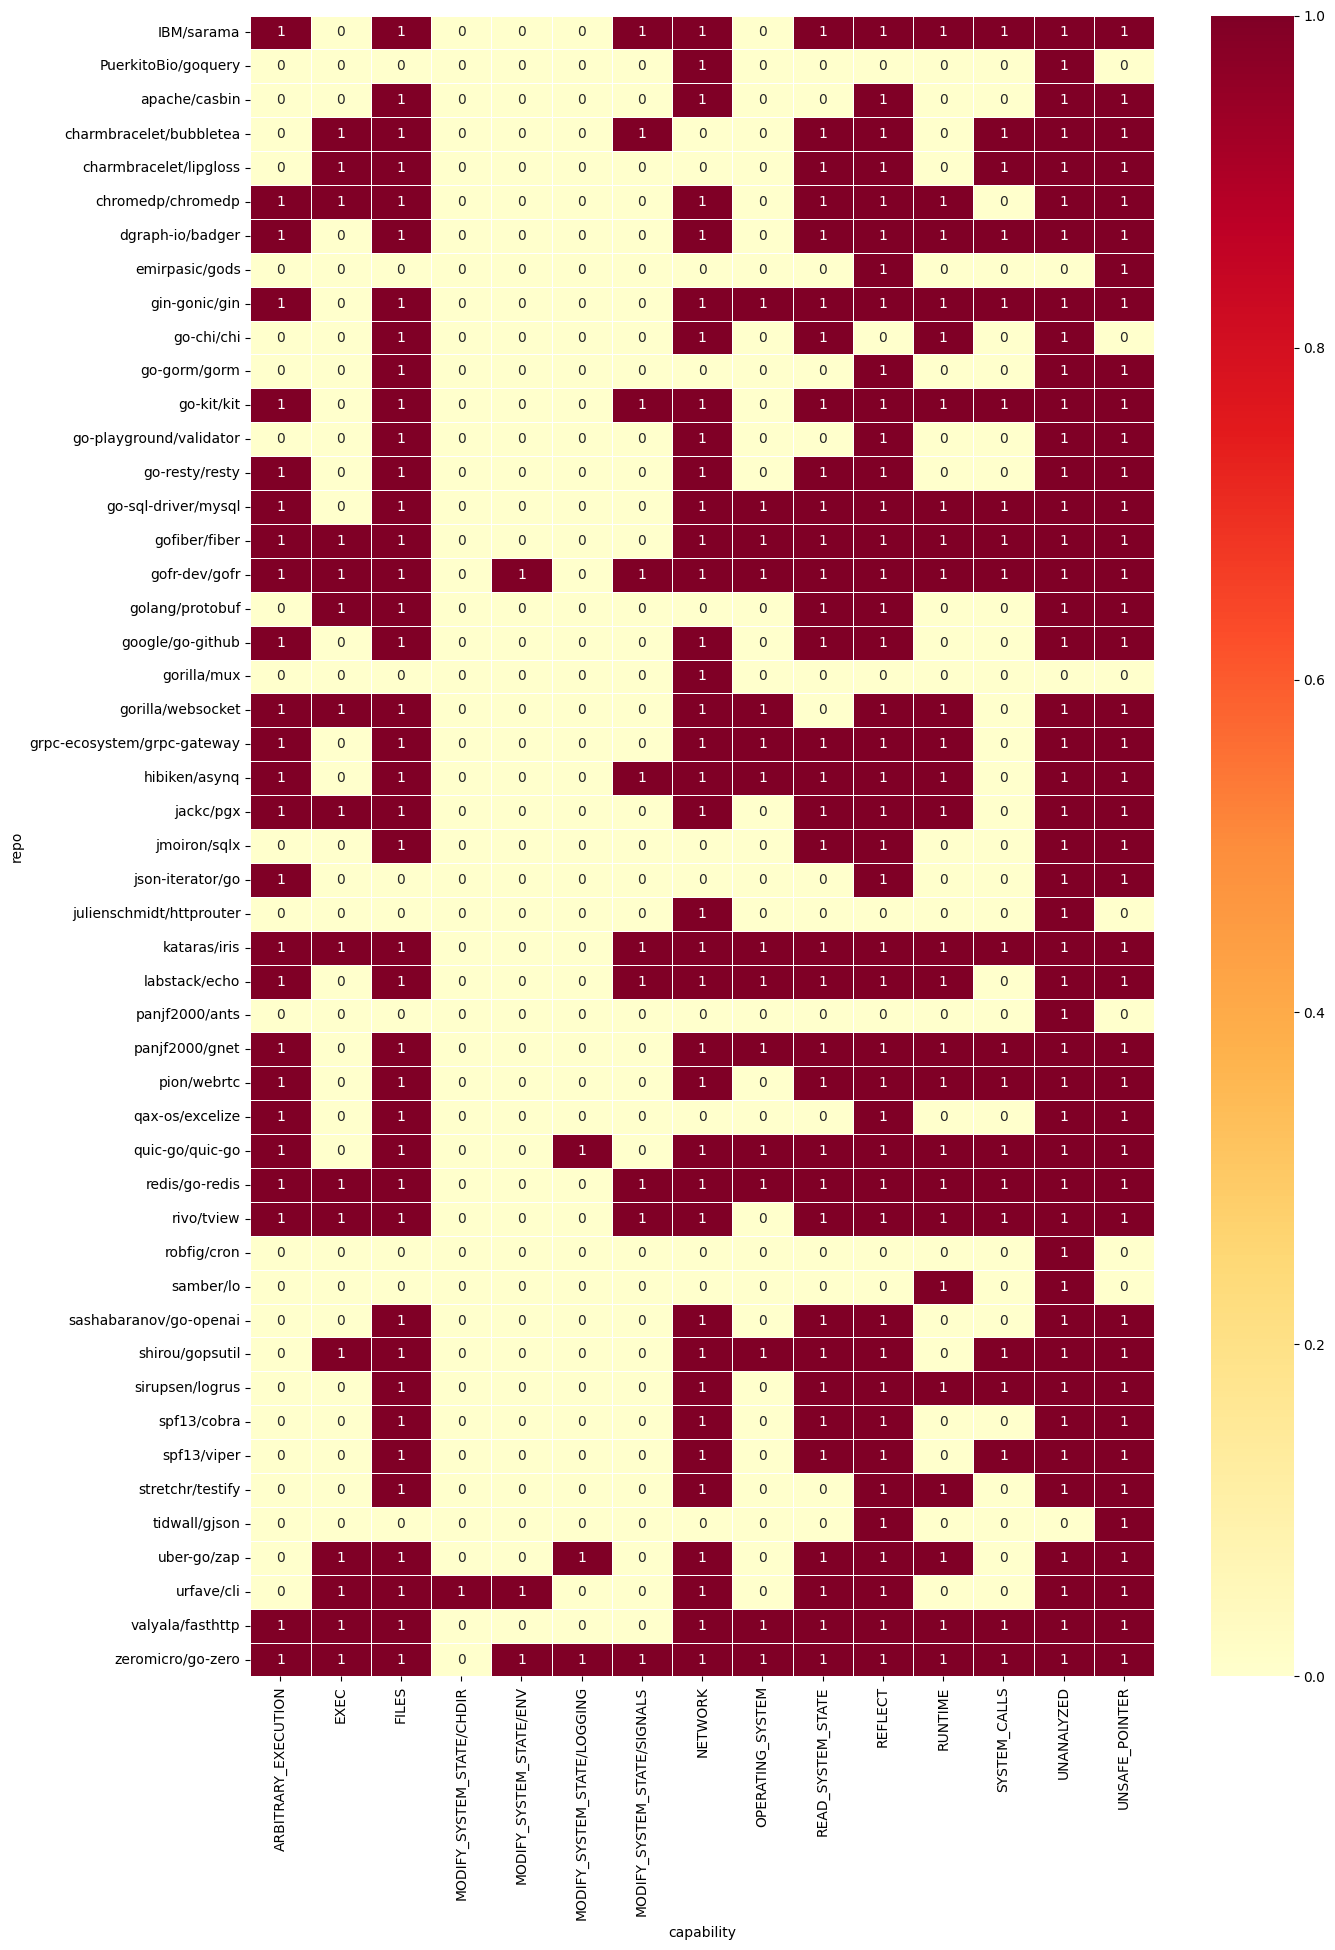

In [4]:
# pivot = df.groupby(["repo", "capability"]).size().unstack(fill_value=0)
pivot = df.groupby(["repo", "capability"]).size().unstack(fill_value=0).gt(0).astype(int)

fig, ax = plt.subplots(figsize=(14, len(pivot) * 0.4))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.5, annot=True, fmt="d")
plt.tight_layout()
plt.show()